In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/bike-sharing-demand/sampleSubmission.csv
/kaggle/input/competitions/bike-sharing-demand/train.csv
/kaggle/input/competitions/bike-sharing-demand/test.csv


## 1. 데이터 확인

In [2]:
import numpy as np
import pandas as pd

data_path = '/kaggle/input/competitions/bike-sharing-demand/'

train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sampleSubmission.csv')

In [3]:
train.shape, test.shape

((10886, 12), (6493, 9))

In [4]:
train.head()
#초기5행

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
test.head

# 분석 결과 : casual, registered 제거

<bound method NDFrame.head of                  datetime  season  holiday  workingday  weather   temp  \
0     2011-01-20 00:00:00       1        0           1        1  10.66   
1     2011-01-20 01:00:00       1        0           1        1  10.66   
2     2011-01-20 02:00:00       1        0           1        1  10.66   
3     2011-01-20 03:00:00       1        0           1        1  10.66   
4     2011-01-20 04:00:00       1        0           1        1  10.66   
...                   ...     ...      ...         ...      ...    ...   
6488  2012-12-31 19:00:00       1        0           1        2  10.66   
6489  2012-12-31 20:00:00       1        0           1        2  10.66   
6490  2012-12-31 21:00:00       1        0           1        1  10.66   
6491  2012-12-31 22:00:00       1        0           1        1  10.66   
6492  2012-12-31 23:00:00       1        0           1        1  10.66   

       atemp  humidity  windspeed  
0     11.365        56    26.0027  
1     13.

In [6]:
submission.head()

# 분석 결과 : datetime 피쳐 제거하기

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


In [7]:
train.info()
#결측값(null) 없는지 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


## 2. 데이터 시각화

In [9]:
#datetime은 그 형태가 시각화에 적합하지 않아서 피처 엔지니어링 적용
print(train['datetime'][1001].split())
print(train['datetime'][1001].split()[1])
print(train['datetime'][1001].split()[1].split(':')[0])

['2011-03-06', '04:00:00']
04:00:00
04


In [10]:
train['year'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[0]) #lambd로 순회
train['month'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[1])
train['day'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[2])
train['hour'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[0])
train['minute'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[1])
train['second'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[2])
train['date'] = train['datetime'].apply(lambda x: x.split()[0])

apply : 다른 열에 편집가해서 새 열 리턴 (피쳐 생성)

In [11]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,date
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,01,01,00,00,00,2011-01-01
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,01,01,01,00,00,2011-01-01
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,01,01,02,00,00,2011-01-01
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,01,01,03,00,00,2011-01-01
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,01,01,04,00,00,2011-01-01


In [12]:
from datetime import datetime
import calendar

print(train['date'][100])
print(datetime.strptime(train['date'][100], '%Y-%m-%d'))
#딱 정해진 datetime 라이브러리의 형식

2011-01-05
2011-01-05 00:00:00


In [13]:
print(datetime.strptime(train['date'][100], '%Y-%m-%d').weekday())
#이걸 가지고...

2


In [14]:
print(calendar.day_name[datetime.strptime(train['date'][100], '%Y-%m-%d').weekday()])

Wednesday


왜 귀찮게 날짜 > 요일로 안가고 날짜 > 몇번째 요일 > 요일 로 가는가?


머신러닝 학습시 숫자만 가능하니까 이 기능이 우선이다. 요일로 바꾼건 보기 쉬우라고...

반대로 학습시엔 요일로 바꾼거 쓰면 안된다!


In [15]:
train['weekday'] = train['date'].apply(lambda x: calendar.day_name[datetime.strptime(x, '%Y-%m-%d').weekday()])

In [16]:
train.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,date,weekday
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,19,00,00,2012-12-19,Wednesday
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,20,00,00,2012-12-19,Wednesday
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,00,00,2012-12-19,Wednesday
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,00,00,2012-12-19,Wednesday
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012,12,19,23,00,00,2012-12-19,Wednesday


이후 date와 month 피쳐는 중복되므로 제거

시각화 실시


In [17]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

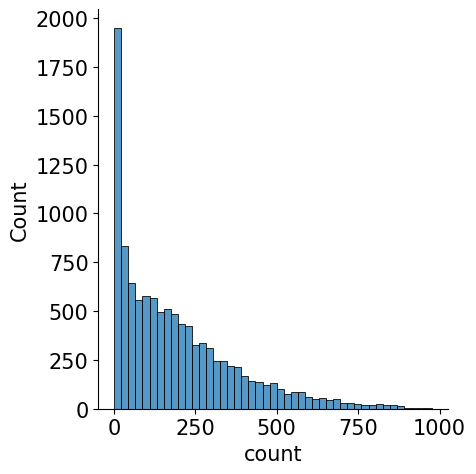

In [18]:
mpl.rc('font', size=15)
sns.displot(train['count']) #seaborn은 matplotlib 기반으 동작

타깃값 훈련 데이터가 정규분포를 따르지 않는다.. 

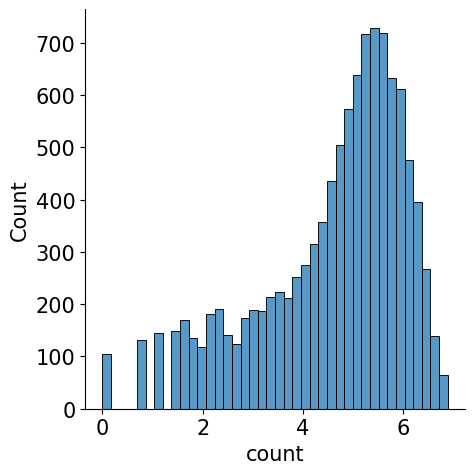

In [19]:
sns.displot(np.log(train['count']))

조금 더 나아졌다..

그 다음 연도, 월, 일, 시, 분 ,초 같은 연관 자료형 보려는데, 도움되는 방법은?

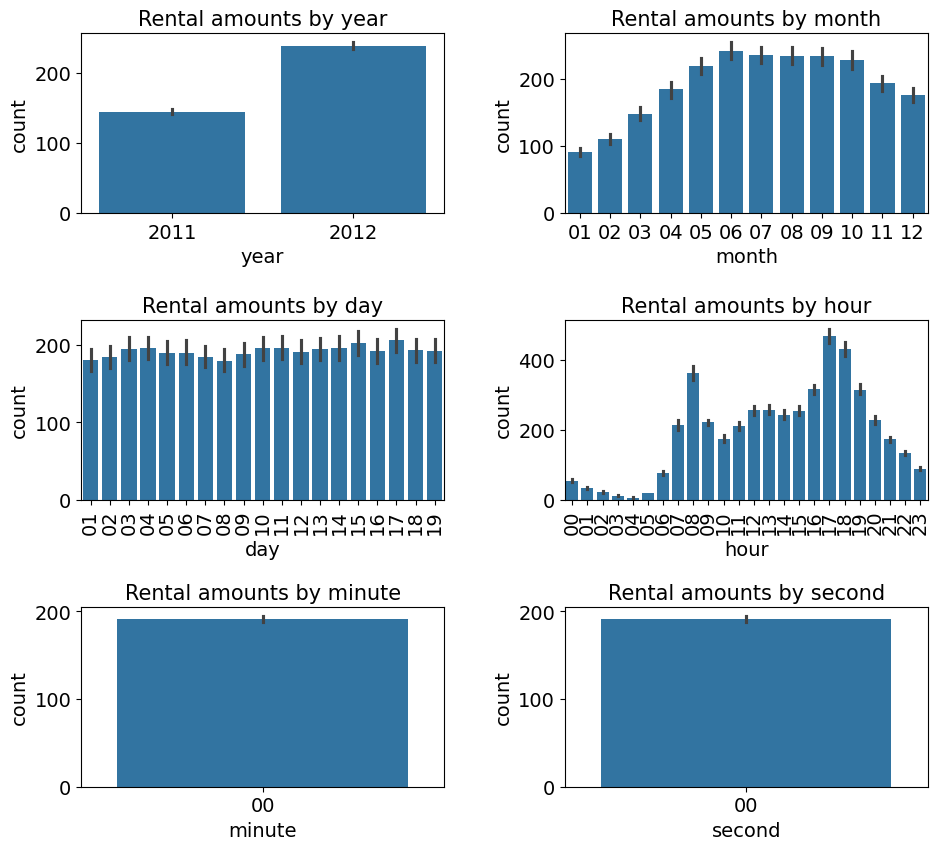

In [20]:
#한번에 실행해야 함!

#step1 : figure 준비
mpl.rc('font', size=14)
mpl.rc('axes', titlesize=15)
figure, axes = plt.subplots(nrows=3, ncols=2) #3행 2열 figure 생성,
#figure에 figure 단일 개체, axes에 figure 속 서브플롯 축 2차원 리스트 형태로 할당 (추후 호출)
plt.tight_layout() #간격 넓히기
figure.set_size_inches(10,9) #전체 figure 크기 10*9인치

#step2 : 할당
sns.barplot(x='year', y='count', data=train, ax=axes[0,0]) #자리 배정
sns.barplot(x='month', y='count', data=train, ax=axes[0,1]) 
sns.barplot(x='day', y='count', data=train, ax=axes[1,0]) 
sns.barplot(x='hour', y='count', data=train, ax=axes[1,1]) 
sns.barplot(x='minute', y='count', data=train, ax=axes[2,0]) 
sns.barplot(x='second', y='count', data=train, ax=axes[2,1]) 

#step3 : 세부 항목 필요시 설정
axes[0,0].set(title='Rental amounts by year')
axes[0,1].set(title='Rental amounts by month')
axes[1,0].set(title='Rental amounts by day')
axes[1,1].set(title='Rental amounts by hour')
axes[2,0].set(title='Rental amounts by minute')
axes[2,1].set(title='Rental amounts by second')

axes[1,0].tick_params(axis='x', labelrotation=90)
axes[1,1].tick_params(axis='x', labelrotation=90) #axis = x,y,both
#라벨이 넘 많으니


<Axes: xlabel='hour', ylabel='count'>

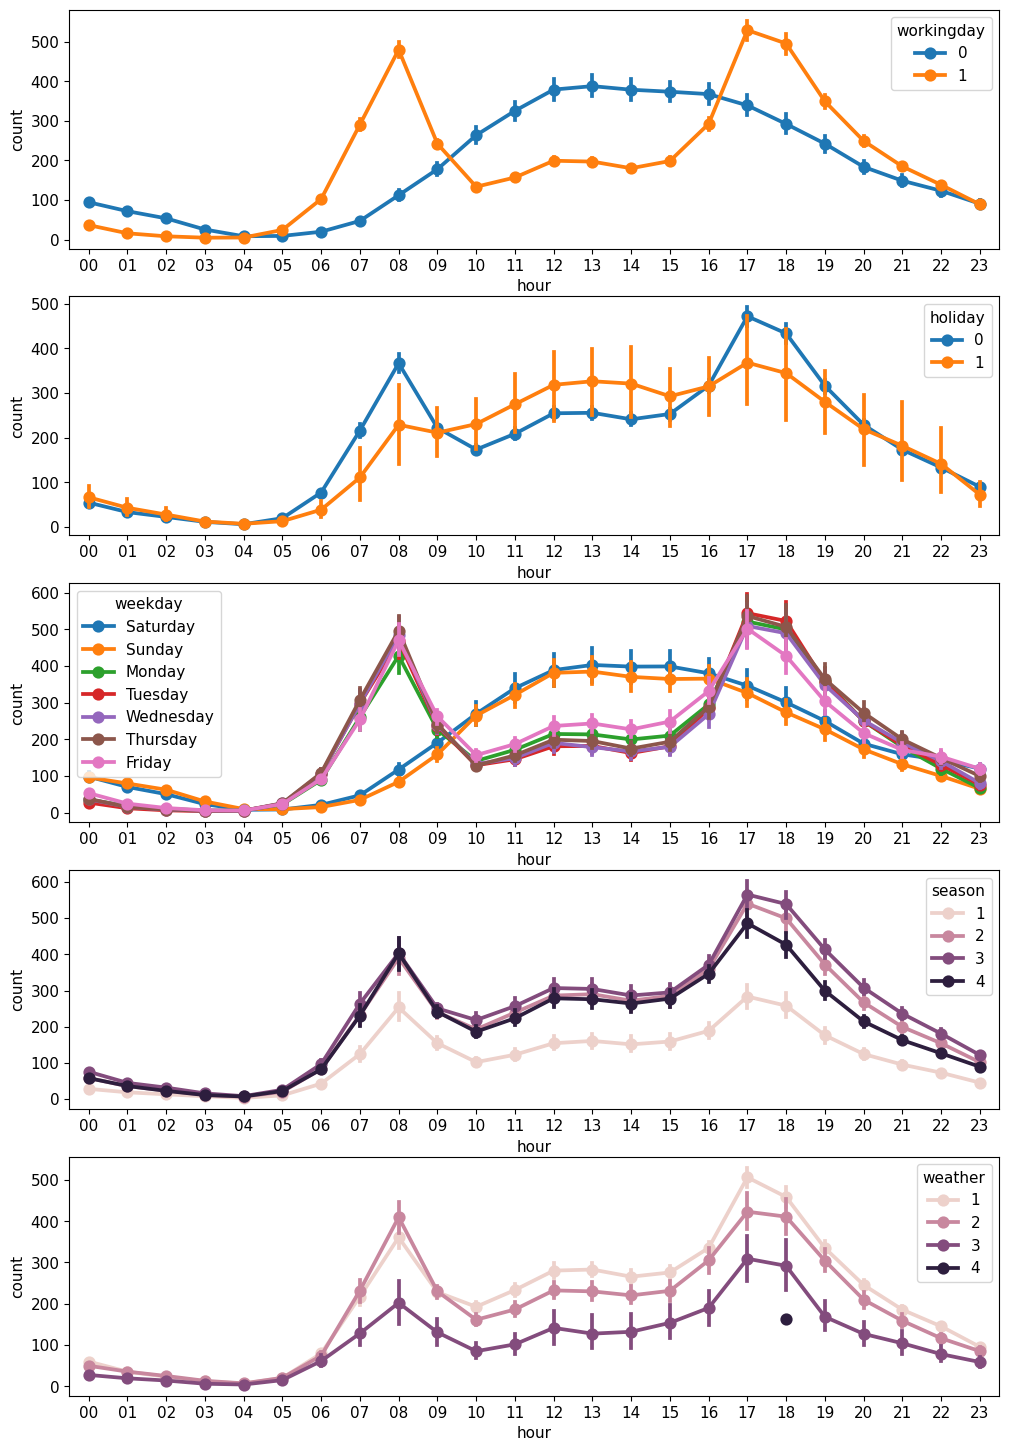

In [21]:
#step1 : figure 준비
mpl.rc('font', size=11)
figure, axes = plt.subplots(nrows=5) #3행 2열 figure 생성,
figure.set_size_inches(12,18) 


sns.pointplot(x='hour', y='count', data=train, hue='workingday', ax=axes[0])
sns.pointplot(x='hour', y='count', data=train, hue='holiday', ax=axes[1])
sns.pointplot(x='hour', y='count', data=train, hue='weekday', ax=axes[2])
sns.pointplot(x='hour', y='count', data=train, hue='season', ax=axes[3])
sns.pointplot(x='hour', y='count', data=train, hue='weather', ax=axes[4])


이상치가 마지막 (날씨) 포인트플롯에서 발견 -> 제거 or 제거 안할지 고민하기

<Axes: xlabel='humidity', ylabel='count'>

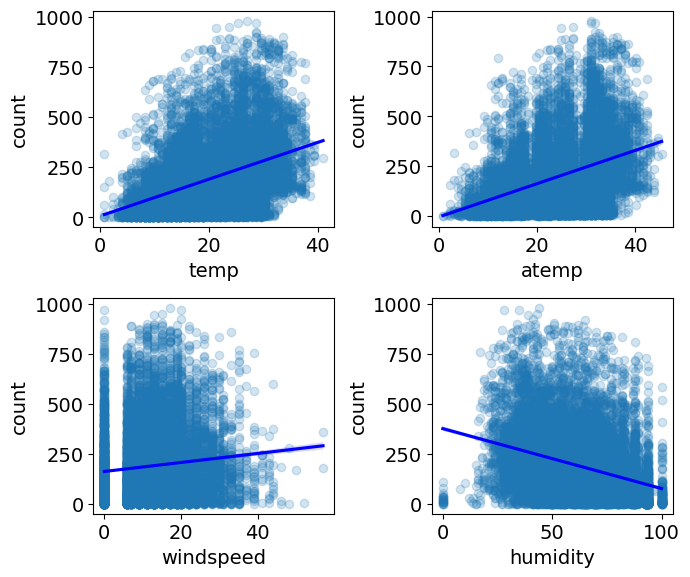

In [22]:
mpl.rc('font', size=14)
figure, axes = plt.subplots(nrows=2, ncols=2)
plt.tight_layout()
figure.set_size_inches(7, 6)

sns.regplot(x='temp', y='count', data=train, ax=axes[0,0], scatter_kws={'alpha': 0.2}, line_kws={'color': 'blue'})
#alpha - 투명도
sns.regplot(x='atemp', y='count', data=train, ax=axes[0,1], scatter_kws={'alpha': 0.2}, line_kws={'color': 'blue'})
sns.regplot(x='windspeed', y='count', data=train, ax=axes[1,0], scatter_kws={'alpha': 0.2}, line_kws={'color': 'blue'})
sns.regplot(x='humidity', y='count', data=train, ax=axes[1,1], scatter_kws={'alpha': 0.2}, line_kws={'color': 'blue'})

In [23]:
#수치형 데이터(위에)끼리 어떤 상관관계 있는지 확인할 수 있다.
train[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


[Text(0.5, 1.0, 'Heatmap')]

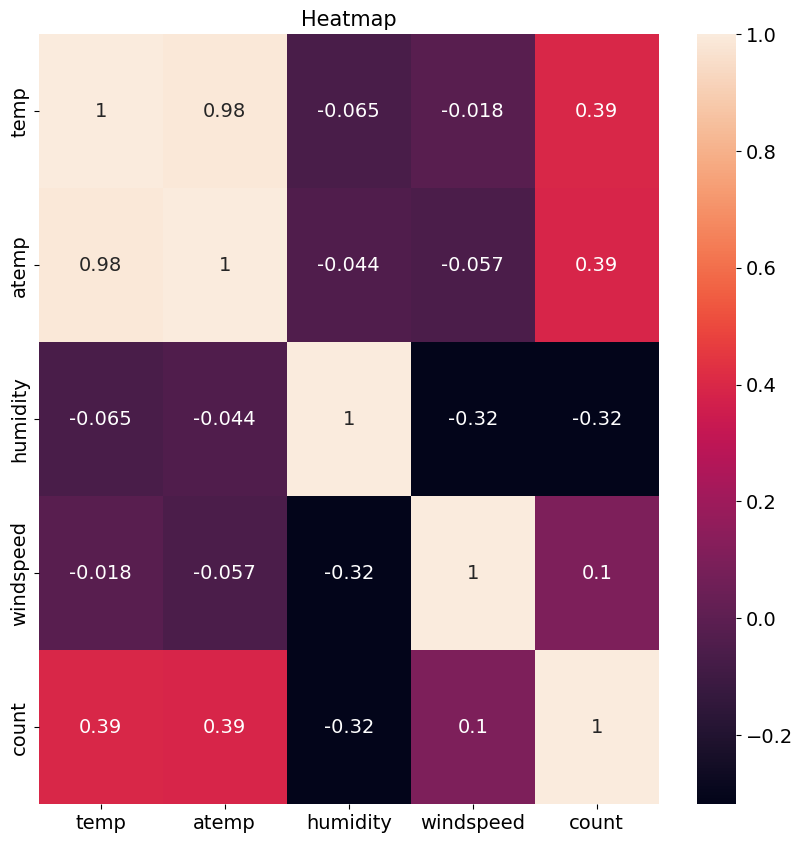

In [24]:
#좀 보기 어려우니...
corrMat = train[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sns.heatmap(corrMat, annot=True) #히트맵!
ax.set(title='Heatmap')


타깃값(count)과 피처간의 상관 관계를 여기서 본다

1. temp : 양의 상관 관계를 가지고 의미 있다
2. humidity : 음의 상관 관계를 가지고 의미 있다.
3. windspeed : 상관 관계 약하며, 풍속은 결측치 데이터도 있는 것으로 보여(regplot) 피처 제거하기로 함

이제 발견한 사실로 피쳐 엔지니어링 / 모델 설계

In [25]:
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sampleSubmission.csv')

In [26]:
train = train[train['weather'] != 4] #weather가 4(이상치)가 아닌 데이터

In [27]:
all_data_temp = pd.concat([train, test]) #피쳐 엔지니어링 일괄 적용 위해서
all_data_temp

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN


In [28]:
#저렇게 하면 원래 있던 인덱스를 각각 부여하므로

all_data = pd.concat([train, test], ignore_index=True)
all_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
17373,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17374,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17375,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN
17376,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN


In [29]:
#파생 피처
all_data['date'] = all_data['datetime'].apply(lambda x : x.split()[0])
all_data['year'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[0])
all_data['month'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[1])
all_data['day'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[2])
all_data['hour'] = all_data['datetime'].apply(lambda x : x.split()[1].split(':')[0])
#day (훈련-평가 다름) minute second (의미 x) 제외
all_data['weekday'] = all_data['date'].apply(lambda dateString : datetime.strptime(dateString, "%Y-%m-%d").weekday())

In [30]:
all_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,year,month,day,hour,weekday
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0,2011-01-01,2011,01,01,00,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0,2011-01-01,2011,01,01,01,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0,2011-01-01,2011,01,01,02,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0,2011-01-01,2011,01,01,03,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0,2011-01-01,2011,01,01,04,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17373,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,2012,12,31,19,0
17374,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,2012,12,31,20,0
17375,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,2012,12,31,21,0
17376,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN,2012-12-31,2012,12,31,22,0


In [31]:
drop_features = ['casual', 'registered', 'datetime', 'date', 'month', 'windspeed']

In [32]:
all_data = all_data.drop(drop_features, axis = 1)

In [33]:
all_data

,season,holiday,workingday,weather,temp,atemp,humidity,count,year,day,hour,weekday
0,1,0,0,1,9.84,14.395,81,16.0,2011,01,00,5
1,1,0,0,1,9.02,13.635,80,40.0,2011,01,01,5
2,1,0,0,1,9.02,13.635,80,32.0,2011,01,02,5
3,1,0,0,1,9.84,14.395,75,13.0,2011,01,03,5
4,1,0,0,1,9.84,14.395,75,1.0,2011,01,04,5
...,...,...,...,...,...,...,...,...,...,...,...,...
17373,1,0,1,2,10.66,12.880,60,NaN,2012,31,19,0
17374,1,0,1,2,10.66,12.880,60,NaN,2012,31,20,0
17375,1,0,1,1,10.66,12.880,60,NaN,2012,31,21,0
17376,1,0,1,1,10.66,13.635,56,NaN,2012,31,22,0


피처 엔지니어링 끝


In [34]:
#다시 나누기

X_train = all_data[~pd.isnull(all_data['count'])] #count가 없는게 test임을 이용
X_test = all_data[pd.isnull(all_data['count'])]

X_train = X_train.drop(['count'], axis=1) #저렇게 나누면 count 포함됨
X_test = X_test.drop(['count'], axis=1)

y = train['count']

In [35]:
X_train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,year,day,hour,weekday
0,1,0,0,1,9.84,14.395,81,2011,01,00,5
1,1,0,0,1,9.02,13.635,80,2011,01,01,5
2,1,0,0,1,9.02,13.635,80,2011,01,02,5
3,1,0,0,1,9.84,14.395,75,2011,01,03,5
4,1,0,0,1,9.84,14.395,75,2011,01,04,5


In [36]:
len(X_train)

10885

In [37]:
len(X_test)

6493

In [38]:
import numpy as np

In [39]:
#평가지표
def rmsle(y_true, y_pred, convertExp=True):

    if convertExp:
        y_true = np.exp(y_true) #로그로 타깃값 하기로 했으니까
        y_pred = np.exp(y_pred)

    log_true = np.nan_to_num(np.log(y_true+1)) #nan을 0으로
    log_pred = np.nan_to_num(np.log(y_pred+1))

    output = np.sqrt(np.mean((log_true - log_pred)**2))
    return output

In [40]:
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression() #원래 이 과정이 중요한데 일단 이번 장에서는 생략

log_y = np.log(y) #타깃값을 정규분포처럼...
linear_reg_model.fit(X_train, log_y)

#predicts
preds = linear_reg_model.predict(X_train)

In [41]:
print(f'{rmsle(log_y, preds, True):.4f}')

1.0203


In [42]:
linearreg_preds = linear_reg_model.predict(X_test)

submission['count'] = np.exp(linearreg_preds)
submission.to_csv('submission.csv', index=False)

제출! - 만족 X -> 피처 엔지니어링, 하이퍼파라미터 최적화 다시 고려해보기

In [43]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

ridge_model = Ridge() #일반 선형회귀 -> Ridge Model
#alpha를 적당한 크기로 조절해(파라미터 최적화) 과대적합 해결

ridge_params = {'max_iter':[3000], 'alpha':[0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000]} #이 조합을 해봐라

rmsle_scorer = metrics.make_scorer(rmsle, greater_is_better=False) #교차검증 시 평가조건
gridsearch_ridge_model = GridSearchCV(estimator=ridge_model, param_grid=ridge_params, scoring=rmsle_scorer, cv=5) #교차검증 분할 수 : cv
#데이터 많고 복잡하면 엄청 걸릴거지만...

log_y = np.log(y)
gridsearch_ridge_model.fit(X_train, log_y)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400,
                                   800, 900, 1000],
                         'max_iter': [3000]},
             scoring=make_scorer(rmsle, greater_is_better=False, response_method='predict'))

In [44]:
print(gridsearch_ridge_model.best_params_)

{'alpha': 0.1, 'max_iter': 3000}


최적 결과는 그렇다

In [45]:
predict =  gridsearch_ridge_model.best_estimator_.predict(X_train)

In [46]:
print(f'{rmsle(log_y, predict, True):.4f}')
len(predict)

1.0203


10885

In [47]:
#걍 더 나아지지 않음

In [48]:
#아래의 Lasso도..

from sklearn.linear_model import Lasso

lasso_model = Lasso()
lasso_alpha = 1/np.array([0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000])
lasso_params = {'max_iter':[3000], 'alpha':lasso_alpha} #why 1/?

gridsearch_lasso_model = GridSearchCV(estimator=lasso_model, param_grid=lasso_params, scoring=rmsle_scorer, cv=5)

log_y = np.log(y)
gridsearch_lasso_model.fit(X_train, log_y)

print(gridsearch_lasso_model.best_params_)
preds =  gridsearch_lasso_model.best_estimator_.predict(X_train)

print(f'{rmsle(log_y, preds, True):.4f}')

{'alpha': np.float64(0.00125), 'max_iter': 3000}
1.0203


In [49]:
len(preds)

10885

In [50]:
from sklearn.ensemble import RandomForestRegressor
randomforest_model = RandomForestRegressor()

rf_params = {'random_state':[42], 'n_estimators':[100,120,140]}#choose one
gridsearch_random_forest_model = GridSearchCV(estimator=randomforest_model, param_grid=rf_params, scoring=rmsle_scorer, cv=5)

log_y = np.log(y)
gridsearch_random_forest_model.fit(X_train, log_y)

print(gridsearch_random_forest_model.best_params_)
rf_preds =  gridsearch_random_forest_model.best_estimator_.predict(X_train)
print(f'{rmsle(log_y, rf_preds, True):.4f}')

{'n_estimators': 140, 'random_state': 42}
0.1101


In [51]:
len(rf_preds)

10885

In [52]:
rf_submit =  gridsearch_random_forest_model.best_estimator_.predict(X_test)
submission['count'] = np.exp(rf_submit)
submission.to_csv('submission.csv', index=False)